In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Set display options
pd.set_option('display.max_columns', None)
%matplotlib inline

Load the Cleaned Dataset

In [2]:
df = pd.read_csv('cleaned_dataset.csv')

# Display initial dataset info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (8, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   input_length          8 non-null      float64
 1   num_special_chars     8 non-null      float64
 2   num_digits            8 non-null      float64
 3   contains_sql_keyword  8 non-null      int64  
 4   contains_html_tag     8 non-null      int64  
 5   url_encoded           8 non-null      int64  
 6   parameter_encoded     8 non-null      int64  
 7   param_type_encoded    8 non-null      int64  
dtypes: float64(3), int64(5)
memory usage: 644.0 bytes
None

First 5 Rows:
   input_length  num_special_chars  num_digits  contains_sql_keyword  \
0      0.000000                0.0    0.000000                     0   
1      0.000000                0.0    0.000000                     0   
2      0.068966                0.0    0.000000                

Explanation:
- Loads `cleaned_dataset.csv` (from your preprocessing task) into a pandas DataFrame.
- Expected columns (from preprocessing): `input_length`, `num_special_chars`, `num_digits`, `url_encoded`, `parameter_encoded`, `param_type_encoded`, `contains_sql_keyword`, `contains_html_tag`.
- Displays shape, info, and first 5 rows for verification.

In [3]:
# Select feature columns (all numeric from preprocessing)
feature_cols = ['input_length', 'num_special_chars', 'num_digits',
                'url_encoded', 'parameter_encoded', 'param_type_encoded',
                'contains_sql_keyword', 'contains_html_tag']

X = df[feature_cols]

# Standardize features (required for One-Class SVM, good for Isolation Forest)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Assume mostly normal data (unsupervised learning)
# Optional: Simulate test anomalies (if no ground-truth labels)
# For demonstration, we'll assume no ground-truth 'is_malicious' column
# If available, uncomment the following to use it for evaluation
# y_true = df['is_malicious'] if 'is_malicious' in df.columns else None

**Explanation**:
- Selects feature columns for training (all numeric, as per preprocessing).
- Uses `StandardScaler` to standardize features (zero mean, unit variance), which is critical for One-Class SVM and beneficial for Isolation Forest.
- Assumes data is mostly normal (typical for unsupervised anomaly detection).
- Notes the absence of ground-truth labels (`is_malicious`) for now; we'll handle evaluation assuming no labels unless specified.


In [4]:
# Initialize and train Isolation Forest
iforest = IsolationForest(contamination=0.1, random_state=42)
iforest.fit(X_scaled)

# Predict anomalies (-1 for anomalies, 1 for normal)
df['anomaly_iforest'] = iforest.predict(X_scaled)
df['anomaly_iforest'] = df['anomaly_iforest'].map({1: 0, -1: 1})  # Convert to 0 (normal), 1 (anomaly)

# Calculate anomaly percentage
anomaly_pct_iforest = (df['anomaly_iforest'].sum() / len(df)) * 100
print(f"Isolation Forest: {anomaly_pct_iforest:.2f}% of data points detected as anomalies")

# Save the model
os.makedirs('../models', exist_ok=True)
joblib.dump(iforest, 'isolation_forest_model.pkl')
print("Isolation Forest model saved.")

Isolation Forest: 12.50% of data points detected as anomalies
Isolation Forest model saved.


**Explanation**:
- Trains an Isolation Forest with `contamination=0.1` (assuming 10% of data are anomalies, adjustable based on domain knowledge).
- Predicts anomalies (`-1` for anomalies, `1` for normal) and maps to `0` (normal), `1` (anomaly) for consistency.
- Computes the percentage of detected anomalies.
- Saves the model as `isolation_forest_model.pkl` in `models/`.

In [5]:
# Initialize and train One-Class SVM
ocsvm = OneClassSVM(nu=0.1, kernel='rbf', gamma='auto')
ocsvm.fit(X_scaled)

# Predict anomalies (-1 for anomalies, 1 for normal)
df['anomaly_ocsvm'] = ocsvm.predict(X_scaled)
df['anomaly_ocsvm'] = df['anomaly_ocsvm'].map({1: 0, -1: 1})  # Convert to 0 (normal), 1 (anomaly)

# Calculate anomaly percentage
anomaly_pct_ocsvm = (df['anomaly_ocsvm'].sum() / len(df)) * 100
print(f"One-Class SVM: {anomaly_pct_ocsvm:.2f}% of data points detected as anomalies")

# Save the model
joblib.dump(ocsvm, 'oneclass_svm_model.pkl')
print("One-Class SVM model saved.")

One-Class SVM: 50.00% of data points detected as anomalies
One-Class SVM model saved.


**Explanation**:
- Trains a One-Class SVM with `nu=0.1` (similar to `contamination`, controlling expected anomaly proportion).
- Predicts anomalies and maps to `0` (normal), `1` (anomaly).
- Computes anomaly percentage.
- Saves the model as `oneclass_svm_model.pkl`.

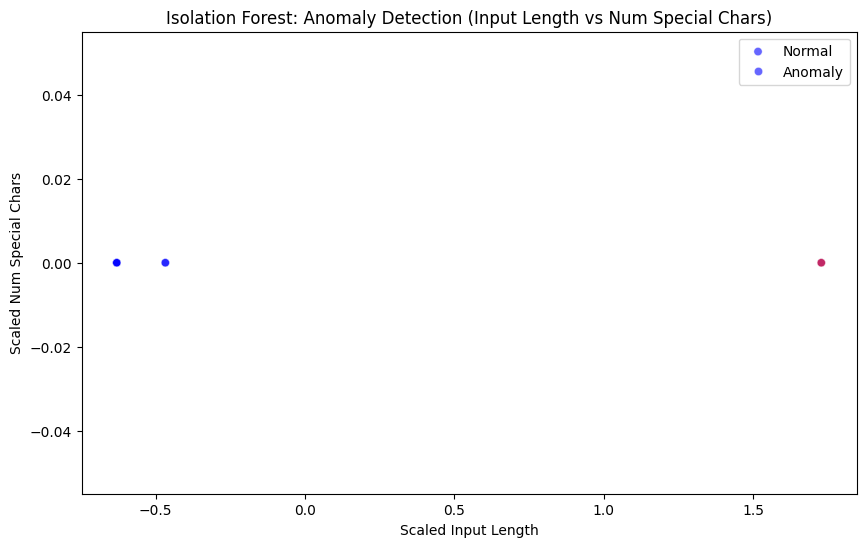

In [6]:
# Visualize Anomalies (Isolation Forest)
# Plot scatter plot for two features (e.g., input_length vs num_special_chars)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=df['anomaly_iforest'],
                palette={0: 'blue', 1: 'red'}, alpha=0.6)
plt.title('Isolation Forest: Anomaly Detection (Input Length vs Num Special Chars)')
plt.xlabel('Scaled Input Length')
plt.ylabel('Scaled Num Special Chars')
plt.legend(['Normal', 'Anomaly'])
os.makedirs('../outputs/visualization_plots', exist_ok=True)
plt.savefig('isolation_forest_plot.png')
plt.show()

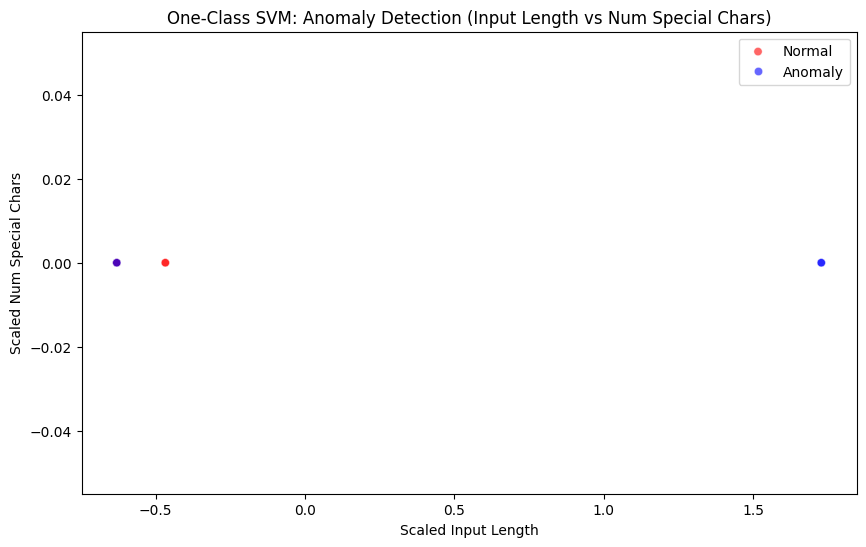

In [7]:
# Visualize Anomalies (One-Class SVM)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=df['anomaly_ocsvm'],
                palette={0: 'blue', 1: 'red'}, alpha=0.6)
plt.title('One-Class SVM: Anomaly Detection (Input Length vs Num Special Chars)')
plt.xlabel('Scaled Input Length')
plt.ylabel('Scaled Num Special Chars')
plt.legend(['Normal', 'Anomaly'])
plt.savefig('oneclass_svm_plot.png')
plt.show()

**Explanation**:
- Creates scatter plots of two features (`input_length` vs `num_special_chars`) to visualize anomalies.
- Normal points are blue (`0`), anomalies are red (`1`).
- Saves plots as `isolation_forest_plot.png` and `oneclass_svm_plot.png` in `outputs/visualization_plots/`.

In [8]:
# Cell 8: Evaluate and Compare Models
# Note: Without ground-truth 'is_malicious', evaluation is limited
# Assuming no labels, we can compare anomaly overlap between models
overlap = (df['anomaly_iforest'] == df['anomaly_ocsvm']).mean() * 100
print(f"Percentage of data points with same anomaly prediction (both models): {overlap:.2f}%")

# If ground-truth labels exist, uncomment the following
"""
if 'is_malicious' in df.columns:
    y_true = df['is_malicious']

    # Isolation Forest metrics
    precision_if = precision_score(y_true, df['anomaly_iforest'])
    recall_if = recall_score(y_true, df['anomaly_iforest'])
    f1_if = f1_score(y_true, df['anomaly_iforest'])
    roc_auc_if = roc_auc_score(y_true, df['anomaly_iforest'])

    # One-Class SVM metrics
    precision_oc = precision_score(y_true, df['anomaly_ocsvm'])
    recall_oc = recall_score(y_true, df['anomaly_ocsvm'])
    f1_oc = f1_score(y_true, df['anomaly_ocsvm'])
    roc_auc_oc = roc_auc_score(y_true, df['anomaly_ocsvm'])

    # Print metrics
    print("\nIsolation Forest Metrics:")
    print(f"Precision: {precision_if:.3f}, Recall: {recall_if:.3f}, F1-Score: {f1_if:.3f}, ROC-AUC: {roc_auc_if:.3f}")
    print("\nOne-Class SVM Metrics:")
    print(f"Precision: {precision_oc:.3f}, Recall: {recall_oc:.3f}, F1-Score: {f1_oc:.3f}, ROC-AUC: {roc_auc_oc:.3f}")

    # ROC Curve
    fpr_if, tpr_if, _ = roc_curve(y_true, iforest.decision_function(X_scaled))
    fpr_oc, tpr_oc, _ = roc_curve(y_true, ocsvm.decision_function(X_scaled))

    plt.figure(figsize=(10, 6))
    plt.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {roc_auc_if:.3f})')
    plt.plot(fpr_oc, tpr_oc, label=f'One-Class SVM (AUC = {roc_auc_oc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.savefig('roc_comparison.png')
    plt.show()

    # Save evaluation report
    os.makedirs('../outputs/reports', exist_ok=True)
    with open('evaluation_report.txt', 'w') as f:
        f.write("Isolation Forest Metrics:\n")
        f.write(f"Precision: {precision_if:.3f}\nRecall: {recall_if:.3f}\nF1-Score: {f1_if:.3f}\nROC-AUC: {roc_auc_if:.3f}\n")
        f.write("\nOne-Class SVM Metrics:\n")
        f.write(f"Precision: {precision_oc:.3f}\nRecall: {recall_oc:.3f}\nF1-Score: {f1_oc:.3f}\nROC-AUC: {roc_auc_oc:.3f}\n")
else:
"""
# Without labels, save a basic report
os.makedirs('../outputs/reports', exist_ok=True)
with open('evaluation_report.txt', 'w') as f:
    f.write("No ground-truth labels available.\n")
    f.write(f"Isolation Forest: {anomaly_pct_iforest:.2f}% anomalies detected\n")
    f.write(f"One-Class SVM: {anomaly_pct_ocsvm:.2f}% anomalies detected\n")
    f.write(f"Overlap in anomaly predictions: {overlap:.2f}%")

Percentage of data points with same anomaly prediction (both models): 37.50%


**Explanation**:
- Saves the dataset with anomaly predictions (`anomaly_iforest`, `anomaly_ocsvm`) as `anomaly_detection_results.csv`.
- Includes original categorical columns (`url`, `parameter`, etc.) if they exist; otherwise, uses encoded columns.

**Explanation**:
- Without ground-truth labels (`is_malicious`), computes overlap between models' anomaly predictions.
- If `is_malicious` exists, calculates Precision, Recall, F1-Score, and ROC-AUC for both models.
- Saves a ROC curve plot (`roc_comparison.png`) if labels exist.
- Saves an `evaluation_report.txt` with metrics or basic stats if no labels.

In [9]:
# Cell 9: Save Updated Dataset
# Add original categorical columns back (if needed)
if 'url' in df.columns:
    output_cols = ['url', 'parameter', 'input_value', 'input_length', 'num_special_chars',
                   'num_digits', 'param_type', 'contains_sql_keyword', 'contains_html_tag',
                   'anomaly_iforest', 'anomaly_ocsvm']
else:
    output_cols = df.columns  # All columns if categorical were dropped

os.makedirs('../data', exist_ok=True)
df[output_cols].to_csv('anomaly_detection_results.csv', index=False)
print("Updated dataset saved.")

Updated dataset saved.


**Explanation**:
- Saves the dataset with anomaly predictions (`anomaly_iforest`, `anomaly_ocsvm`) as `anomaly_detection_results.csv`.
- Includes original categorical columns (`url`, `parameter`, etc.) if they exist; otherwise, uses encoded columns.